# Forward-only versus bidirectional baseline masking

This executed sidecar experiment compares the current stateful masker with a proposed time-symmetric hysteresis mask. Production source code is not modified.

The candidate rule retains the current sign-specific thresholds and 5-day padding:

- run the current forward state machine without alteration;
- from the first 3-sigma seed of each current run, step backward while the same-sign residual remains beyond 1 sigma;
- retain every current masked point and add only the qualifying earlier points.

Each injected event is compared with a no-injection realization having identical cadence, noise, and quiescent variability, so the decisive baseline and amplitude metrics isolate injection-induced distortion. The notebook then applies both methods to ASAS-SN 197569146752 as a qualitative real-light-curve check. Seasonal-gap semantics are intentionally left unchanged so the comparison isolates temporal directionality.


In [1]:
from contextlib import contextmanager
from pathlib import Path
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

candidate_roots = [Path.cwd().resolve(), *Path.cwd().resolve().parents]
repo_root = next(
    (
        path
        for path in candidate_roots
        if (path / "pyproject.toml").is_file()
        and (path / "malca" / "core" / "baseline.py").is_file()
    ),
    None,
)
if repo_root is None:
    raise RuntimeError(f"Could not find the MALCA repository above {Path.cwd()}")
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import malca.core.baseline as baseline_module
from malca.core.utils import clean_lc
from malca.io.lightcurve_io import load_lightcurve_df, to_asassn_algorithm_frame
from malca.plotting.lightcurve_publication import (
    FIG_TWO_COL_WIDTH,
    PUBLICATION_STYLE,
    finalize_publication_figure,
)
from malca.stv.events import DEFAULT_BASELINE_KWARGS

warnings.filterwarnings("ignore", category=RuntimeWarning)

TARGET_ID = "197569146752"
RUN_ROOT = repo_root / "output" / "runs" / "dat3-full-extended_2026-07-01-v4"
LIGHTCURVE_PATH = RUN_ROOT / "bundle_assets" / "lightcurves" / f"{TARGET_ID}.dat3"
OUTPUT_DIR = repo_root / "output" / "pdf" / "baseline_methods" / "mask_direction_comparison"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SYNTHETIC_PDF = OUTPUT_DIR / "bidirectional_mask_synthetic_example.pdf"
SYNTHETIC_PNG = OUTPUT_DIR / "bidirectional_mask_synthetic_example.png"
MONTE_CARLO_PDF = OUTPUT_DIR / "bidirectional_mask_paired_trials.pdf"
MONTE_CARLO_PNG = OUTPUT_DIR / "bidirectional_mask_paired_trials.png"
TRIAL_METRICS_CSV = OUTPUT_DIR / "bidirectional_mask_trial_metrics.csv"
TRIAL_SUMMARY_CSV = OUTPUT_DIR / "bidirectional_mask_trial_summary.csv"
REAL_PDF = OUTPUT_DIR / f"bidirectional_mask_real_{TARGET_ID}_g.pdf"
REAL_PNG = OUTPUT_DIR / f"bidirectional_mask_real_{TARGET_ID}_g.png"
REAL_METRICS_CSV = OUTPUT_DIR / f"bidirectional_mask_real_{TARGET_ID}_g.csv"

BASELINE_KWARGS = dict(DEFAULT_BASELINE_KWARGS)
N_EVENT_TRIALS = 120
N_CONTROL_TRIALS = 60
RANDOM_SEED = 20260827

print("Repository:", repo_root)
print("Production baseline source:", baseline_module.__file__)
print("Output directory:", OUTPUT_DIR)


Repository: /Users/calder/code/malca
Production baseline source: /Users/calder/code/malca/malca/core/baseline.py
Output directory: /Users/calder/code/malca/output/pdf/baseline_methods/mask_direction_comparison


In [2]:
original_mask_excursions = baseline_module._mask_excursions


def contiguous_true_runs(mask):
    indices = np.flatnonzero(np.asarray(mask, dtype=bool))
    if indices.size == 0:
        return []
    return np.split(indices, np.flatnonzero(np.diff(indices) > 1) + 1)


def bidirectional_mask_excursions(
    t,
    mag,
    base_rough,
    finite,
    median_mag,
    *,
    mag_err,
    dip_sigma_thresh,
    bright_sigma_thresh,
    pad_days,
):
    """Preserve current forward flags and extend each run backward past 1 sigma."""
    t = np.asarray(t, dtype=float)
    mag = np.asarray(mag, dtype=float)
    base_rough = np.asarray(base_rough, dtype=float)
    finite = np.asarray(finite, dtype=bool)
    mag_err = np.asarray(mag_err, dtype=float)

    current_flags, _current_keep, _current_intervals, s0 = (
        original_mask_excursions(
            t,
            mag,
            base_rough,
            finite,
            median_mag,
            mag_err=mag_err,
            dip_sigma_thresh=dip_sigma_thresh,
            bright_sigma_thresh=bright_sigma_thresh,
            pad_days=pad_days,
        )
    )
    valid = finite & np.isfinite(t) & np.isfinite(mag) & np.isfinite(base_rough)
    flags = np.asarray(current_flags, dtype=bool).copy()

    for run in contiguous_true_runs(current_flags):
        seed = int(run[0])
        seed_baseline = float(base_rough[seed])
        seed_sigma = (float(mag[seed]) - seed_baseline) / float(s0)
        if seed_sigma > float(dip_sigma_thresh):
            continues = lambda value: value > 1.0
        elif seed_sigma < float(bright_sigma_thresh):
            continues = lambda value: value < -1.0
        else:
            continue

        earlier = seed - 1
        while earlier >= 0 and valid[earlier]:
            sigma_here = (float(mag[earlier]) - seed_baseline) / float(s0)
            if not continues(sigma_here):
                break
            flags[earlier] = True
            earlier -= 1

    if np.any(np.asarray(current_flags, bool) & ~flags):
        raise AssertionError("Bidirectional candidate removed a current flag.")

    event_flag = finite & flags
    keep = finite.copy()
    intervals = []
    if event_flag.any():
        bad = np.zeros_like(keep, dtype=bool)
        for event_time in t[event_flag]:
            lo = float(event_time) - float(pad_days)
            hi = float(event_time) + float(pad_days)
            bad |= (t >= lo) & (t <= hi)
            intervals.append((lo, hi))
        keep &= ~bad

    return flags, keep, baseline_module._union_intervals(intervals), s0


@contextmanager
def use_mask_excursions(masker):
    baseline_module._mask_excursions = masker
    try:
        yield
    finally:
        baseline_module._mask_excursions = original_mask_excursions


def run_baseline_pair(lightcurve):
    current = baseline_module.per_camera_gp_baseline_masked(
        lightcurve, **BASELINE_KWARGS
    ).reset_index(drop=True)
    with use_mask_excursions(bidirectional_mask_excursions):
        bidirectional = baseline_module.per_camera_gp_baseline_masked(
            lightcurve, **BASELINE_KWARGS
        ).reset_index(drop=True)
    if baseline_module._mask_excursions is not original_mask_excursions:
        raise AssertionError("Production masker was not restored.")
    return {"current": current, "bidirectional": bidirectional}


print("Current helper:", original_mask_excursions.__name__)
print("Candidate helper:", bidirectional_mask_excursions.__name__)


Current helper: _mask_excursions
Candidate helper: bidirectional_mask_excursions


In [3]:
def synthetic_cadence(rng):
    seasons = (
        np.arange(0.0, 300.0, 3.1),
        np.arange(430.0, 760.0, 3.4),
        np.arange(880.0, 1200.0, 3.0),
    )
    time = np.concatenate(seasons)
    time = time + rng.normal(0.0, 0.45, size=time.size)
    return np.sort(time)


def asymmetric_event_offset(time, center, amplitude, rise_days, fall_days, kind):
    offset = np.zeros_like(time, dtype=float)
    ingress = (time >= center - rise_days) & (time <= center)
    egress = (time > center) & (time <= center + fall_days)
    offset[ingress] = amplitude * (
        (time[ingress] - (center - rise_days)) / rise_days
    )
    offset[egress] = amplitude * (
        1.0 - (time[egress] - center) / fall_days
    )
    if kind == "brightening":
        offset *= -1.0
    return offset


def make_synthetic_lightcurve(
    *,
    seed,
    event_kind="dimming",
    center=620.0,
    amplitude=0.45,
    rise_days=65.0,
    fall_days=12.0,
    baseline_phase=0.0,
    trend_slope=0.000025,
    inject_event=True,
):
    rng = np.random.default_rng(seed)
    time = synthetic_cadence(rng)
    true_baseline = (
        14.0
        + 0.028 * np.sin(2.0 * np.pi * time / 720.0 + baseline_phase)
        + float(trend_slope) * (time - 600.0)
    )
    error = np.full(time.size, 0.022)
    injected_offset = (
        asymmetric_event_offset(
            time, center, amplitude, rise_days, fall_days, event_kind
        )
        if inject_event
        else np.zeros_like(time)
    )
    magnitude = true_baseline + injected_offset + rng.normal(0.0, error)
    return pd.DataFrame(
        {
            "JD": 2458000.0 + time,
            "mag": magnitude,
            "error": error,
            "camera#": "synthetic",
            "v_g_band": 0,
            "saturated": 0,
            "true_baseline": true_baseline,
            "injected_offset": injected_offset,
            "event_center": 2458000.0 + center,
        }
    )


def summarize_pair(
    lightcurve,
    pair,
    *,
    event_kind,
    trial,
    cohort,
    metadata,
    control_pair=None,
):
    truth_baseline = lightcurve["true_baseline"].to_numpy(float)
    injected = lightcurve["injected_offset"].to_numpy(float)
    time = lightcurve["JD"].to_numpy(float)
    center = float(lightcurve["event_center"].iloc[0])
    event_support = np.abs(injected) > 1e-12
    ingress_support = event_support & (time <= center)
    quiet_support = ~event_support
    injected_amplitude = float(np.nanmax(np.abs(injected)))

    rows = []
    for method, result in pair.items():
        masked = result["is_masked"].fillna(False).to_numpy(bool)
        baseline_error = result["baseline"].to_numpy(float) - truth_baseline
        residual = result["resid"].to_numpy(float)
        control_result = (
            control_pair.get(method) if control_pair is not None else None
        )
        if control_result is not None and event_support.any():
            injection_baseline_shift = (
                result["baseline"].to_numpy(float)
                - control_result["baseline"].to_numpy(float)
            )
            differential_residual = (
                residual - control_result["resid"].to_numpy(float)
            )
            paired_control_baseline_rmse = float(
                np.sqrt(
                    np.nanmean(injection_baseline_shift[event_support] ** 2)
                )
            )
            if event_kind == "dimming":
                paired_control_amplitude = float(
                    np.nanmax(differential_residual[event_support])
                )
            elif event_kind == "brightening":
                paired_control_amplitude = float(
                    -np.nanmin(differential_residual[event_support])
                )
            else:
                paired_control_amplitude = np.nan
        else:
            paired_control_baseline_rmse = np.nan
            paired_control_amplitude = np.nan
        if event_support.any() and event_kind == "dimming":
            recovered_amplitude = float(np.nanmax(residual[event_support]))
        elif event_support.any() and event_kind == "brightening":
            recovered_amplitude = float(-np.nanmin(residual[event_support]))
        else:
            recovered_amplitude = np.nan

        rows.append(
            {
                "cohort": cohort,
                "trial": int(trial),
                "event_kind": event_kind,
                "method": method,
                "n_points": int(len(lightcurve)),
                "n_masked": int(masked.sum()),
                "masked_fraction": float(masked.mean()),
                "event_mask_recall": (
                    float(masked[event_support].mean()) if event_support.any() else np.nan
                ),
                "ingress_unmasked_points": (
                    int(np.count_nonzero(ingress_support & ~masked))
                    if ingress_support.any()
                    else 0
                ),
                "quiet_mask_fraction": (
                    float(masked[quiet_support].mean()) if quiet_support.any() else np.nan
                ),
                "event_baseline_rmse_mag": (
                    float(np.sqrt(np.nanmean(baseline_error[event_support] ** 2)))
                    if event_support.any()
                    else np.nan
                ),
                "quiet_baseline_rmse_mag": float(
                    np.sqrt(np.nanmean(baseline_error[quiet_support] ** 2))
                ),
                "injected_amplitude_mag": injected_amplitude,
                "recovered_amplitude_mag": recovered_amplitude,
                "absolute_amplitude_error_mag": (
                    abs(recovered_amplitude - injected_amplitude)
                    if np.isfinite(recovered_amplitude)
                    else np.nan
                ),
                "paired_control_event_baseline_shift_rmse_mag": (
                    paired_control_baseline_rmse
                ),
                "paired_control_recovered_amplitude_mag": (
                    paired_control_amplitude
                ),
                "paired_control_absolute_amplitude_error_mag": (
                    abs(paired_control_amplitude - injected_amplitude)
                    if np.isfinite(paired_control_amplitude)
                    else np.nan
                ),
                **metadata,
            }
        )
    return rows


example = make_synthetic_lightcurve(
    seed=RANDOM_SEED,
    event_kind="dimming",
    center=620.0,
    amplitude=0.45,
    rise_days=65.0,
    fall_days=12.0,
)
example_pair = run_baseline_pair(example)
example_control = make_synthetic_lightcurve(
    seed=RANDOM_SEED,
    event_kind="control",
    center=620.0,
    amplitude=0.45,
    rise_days=65.0,
    fall_days=12.0,
    inject_event=False,
)
example_control_pair = run_baseline_pair(example_control)
example_rows = summarize_pair(
    example,
    example_pair,
    event_kind="dimming",
    trial=0,
    cohort="illustrative_event",
    metadata={"rise_days": 65.0, "fall_days": 12.0},
    control_pair=example_control_pair,
)
example_summary = pd.DataFrame(example_rows).set_index("method")
display(example_summary.T)


method,current,bidirectional
cohort,illustrative_event,illustrative_event
trial,0,0
event_kind,dimming,dimming
n_points,302,302
n_masked,17,18
masked_fraction,0.056291,0.059603
event_mask_recall,0.73913,0.782609
ingress_unmasked_points,6,5
quiet_mask_fraction,0.0,0.0
event_baseline_rmse_mag,0.025419,0.024967


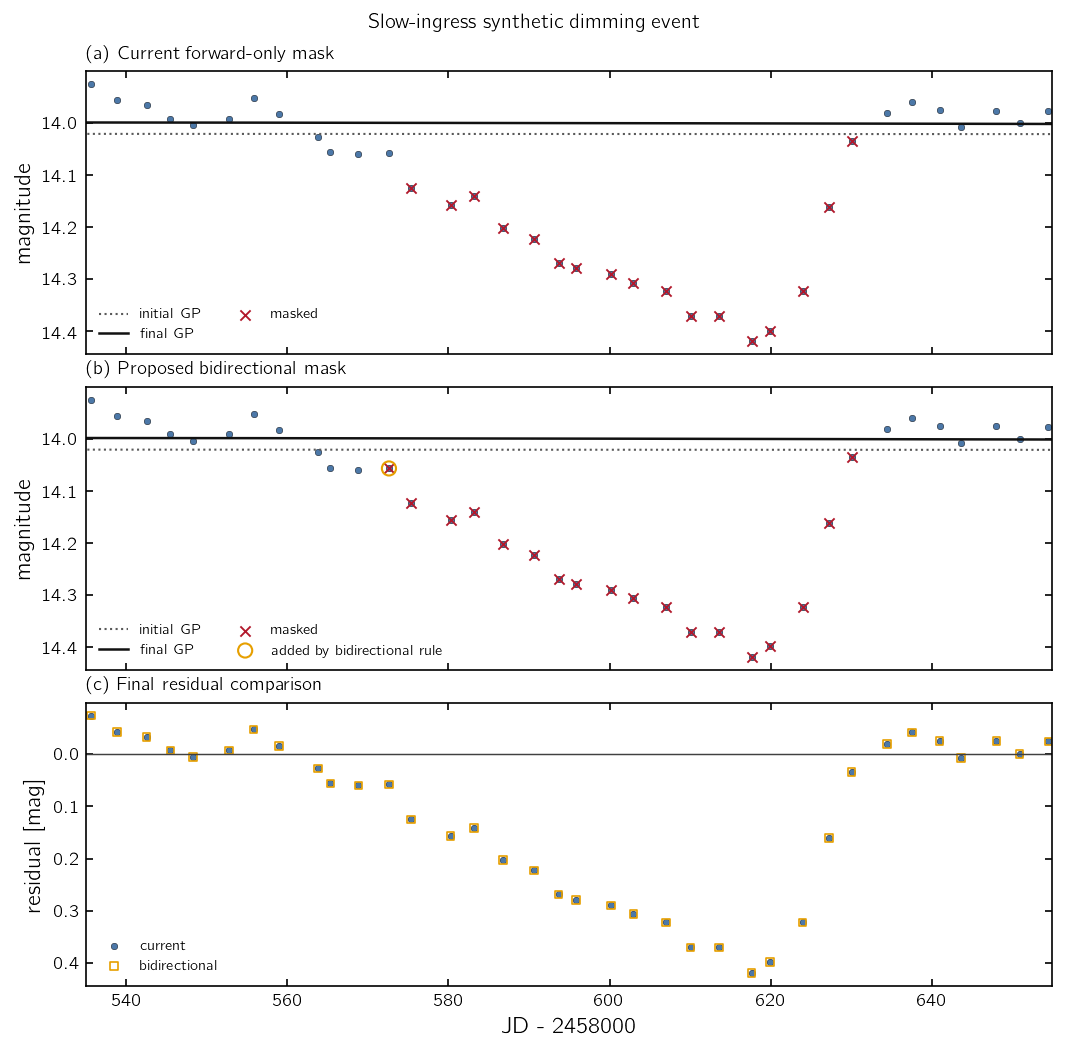

Additional points masked by bidirectional rule: 1
/Users/calder/code/malca/output/pdf/baseline_methods/mask_direction_comparison/bidirectional_mask_synthetic_example.pdf


In [4]:
def plot_baseline_variant(ax, frame, title, *, added_mask=None):
    x = frame["JD"].to_numpy(float) - 2458000.0
    masked = frame["is_masked"].fillna(False).to_numpy(bool)
    ax.scatter(
        x, frame["mag"], s=10, color="#4C78A8", edgecolors="black",
        linewidths=0.2, zorder=2,
    )
    ax.plot(x, frame["base_rough"], ":", color="0.35", linewidth=1.0, label="initial GP")
    ax.plot(x, frame["baseline"], color="#111111", linewidth=1.2, label="final GP")
    ax.scatter(
        x[masked], frame.loc[masked, "mag"], marker="x", s=24,
        color="#B2182B", linewidths=0.9, label="masked",
        zorder=5,
    )
    if added_mask is not None and np.any(added_mask):
        ax.scatter(
            x[added_mask], frame.loc[added_mask, "mag"],
            facecolors="none", edgecolors="#E69F00", s=46,
            linewidths=1.0, label="added by bidirectional rule", zorder=6,
        )
    ax.invert_yaxis()
    ax.set_ylabel("magnitude")
    ax.set_title(title, loc="left", fontsize=9)
    ax.legend(frameon=False, fontsize=7, ncol=2, loc="best")


current_example = example_pair["current"]
bidirectional_example = example_pair["bidirectional"]
added_example = (
    bidirectional_example["is_masked"].fillna(False).to_numpy(bool)
    & ~current_example["is_masked"].fillna(False).to_numpy(bool)
)

with plt.rc_context(PUBLICATION_STYLE):
    fig, axes = plt.subplots(
        3, 1, figsize=(FIG_TWO_COL_WIDTH, 7.0), sharex=True
    )
    plot_baseline_variant(axes[0], current_example, "(a) Current forward-only mask")
    plot_baseline_variant(
        axes[1],
        bidirectional_example,
        "(b) Proposed bidirectional mask",
        added_mask=added_example,
    )

    x = example["JD"].to_numpy(float) - 2458000.0
    axes[2].scatter(
        x, current_example["resid"], s=10, color="#4C78A8",
        edgecolors="black", linewidths=0.2, label="current",
    )
    axes[2].scatter(
        x, bidirectional_example["resid"], s=13, marker="s",
        facecolors="none", edgecolors="#E69F00", linewidths=0.8,
        label="bidirectional",
    )
    axes[2].axhline(0.0, color="0.25", linewidth=0.7)
    axes[2].invert_yaxis()
    axes[2].set_ylabel("residual [mag]")
    axes[2].set_xlabel("JD - 2458000")
    axes[2].set_title("(c) Final residual comparison", loc="left", fontsize=9)
    axes[2].legend(frameon=False, fontsize=7)

    for ax in axes:
        ax.set_xlim(535.0, 655.0)
        ax.tick_params(direction="in", top=True, right=True)
    fig.suptitle("Slow-ingress synthetic dimming event", fontsize=10)
    finalize_publication_figure(fig, rect=(0, 0, 1, 0.98))
    fig.savefig(SYNTHETIC_PDF)
    fig.savefig(SYNTHETIC_PNG, dpi=220)
    plt.show()

print("Additional points masked by bidirectional rule:", int(added_example.sum()))
print(SYNTHETIC_PDF)


In [5]:
rng = np.random.default_rng(RANDOM_SEED)
trial_rows = []

if N_EVENT_TRIALS != 2 * N_CONTROL_TRIALS:
    raise ValueError("N_EVENT_TRIALS must equal twice N_CONTROL_TRIALS.")

for trial in range(N_CONTROL_TRIALS):
    trial_seed = int(rng.integers(0, 2**31 - 1))
    center = float(rng.uniform(555.0, 675.0))
    amplitude = float(rng.uniform(0.18, 0.75))
    rise_days = float(10 ** rng.uniform(np.log10(8.0), np.log10(120.0)))
    fall_days = float(10 ** rng.uniform(np.log10(6.0), np.log10(75.0)))
    baseline_phase = float(rng.uniform(0.0, 2.0 * np.pi))
    trend_slope = float(rng.uniform(-0.00005, 0.00005))
    control_lightcurve = make_synthetic_lightcurve(
        seed=trial_seed,
        event_kind="control",
        center=center,
        amplitude=amplitude,
        rise_days=rise_days,
        fall_days=fall_days,
        baseline_phase=baseline_phase,
        trend_slope=trend_slope,
        inject_event=False,
    )
    control_pair = run_baseline_pair(control_lightcurve)
    trial_rows.extend(
        summarize_pair(
            control_lightcurve,
            control_pair,
            event_kind="control",
            trial=trial,
            cohort="uninjected_control",
            metadata={
                "rise_days": rise_days,
                "fall_days": fall_days,
                "center": center,
                "baseline_phase": baseline_phase,
                "trend_slope": trend_slope,
            },
        )
    )

    for event_kind in ("dimming", "brightening"):
        lightcurve = make_synthetic_lightcurve(
            seed=trial_seed,
            event_kind=event_kind,
            center=center,
            amplitude=amplitude,
            rise_days=rise_days,
            fall_days=fall_days,
            baseline_phase=baseline_phase,
            trend_slope=trend_slope,
        )
        pair = run_baseline_pair(lightcurve)
        trial_rows.extend(
            summarize_pair(
                lightcurve,
                pair,
                event_kind=event_kind,
                trial=trial,
                cohort="injected_event",
                metadata={
                    "rise_days": rise_days,
                    "fall_days": fall_days,
                    "center": center,
                    "baseline_phase": baseline_phase,
                    "trend_slope": trend_slope,
                },
                control_pair=control_pair,
            )
        )

trial_metrics = pd.DataFrame(trial_rows)
trial_metrics.to_csv(TRIAL_METRICS_CSV, index=False)

summary_columns = {
    "n_masked": ["median", "mean"],
    "masked_fraction": ["median", "mean"],
    "event_mask_recall": ["median", "mean"],
    "ingress_unmasked_points": ["median", "mean"],
    "quiet_mask_fraction": ["median", "mean"],
    "event_baseline_rmse_mag": ["median", "mean"],
    "quiet_baseline_rmse_mag": ["median", "mean"],
    "absolute_amplitude_error_mag": ["median", "mean"],
    "paired_control_event_baseline_shift_rmse_mag": ["median", "mean"],
    "paired_control_absolute_amplitude_error_mag": ["median", "mean"],
}
trial_summary = (
    trial_metrics.groupby(["cohort", "event_kind", "method"], dropna=False)
    .agg(summary_columns)
    .reset_index()
)
trial_summary.columns = [
    "_".join(str(value) for value in column if value)
    if isinstance(column, tuple)
    else str(column)
    for column in trial_summary.columns
]
trial_summary.to_csv(TRIAL_SUMMARY_CSV, index=False)
display(trial_summary)

paired_events = trial_metrics.loc[
    trial_metrics["cohort"] == "injected_event"
].pivot(index=["trial", "event_kind"], columns="method")
paired_controls = trial_metrics.loc[
    trial_metrics["cohort"] == "uninjected_control"
].pivot(index=["trial", "event_kind"], columns="method")

event_deltas = pd.DataFrame(
    {
        "rise_days": paired_events["rise_days"]["current"],
        "mask_recall_delta": (
            paired_events["event_mask_recall"]["bidirectional"]
            - paired_events["event_mask_recall"]["current"]
        ),
        "ingress_unmasked_delta": (
            paired_events["ingress_unmasked_points"]["bidirectional"]
            - paired_events["ingress_unmasked_points"]["current"]
        ),
        "event_rmse_delta_mag": (
            paired_events["paired_control_event_baseline_shift_rmse_mag"]["bidirectional"]
            - paired_events["paired_control_event_baseline_shift_rmse_mag"]["current"]
        ),
        "amplitude_error_delta_mag": (
            paired_events["paired_control_absolute_amplitude_error_mag"]["bidirectional"]
            - paired_events["paired_control_absolute_amplitude_error_mag"]["current"]
        ),
        "current_amplitude_error_mag": paired_events[
            "paired_control_absolute_amplitude_error_mag"
        ]["current"],
        "bidirectional_amplitude_error_mag": paired_events[
            "paired_control_absolute_amplitude_error_mag"
        ]["bidirectional"],
    }
).reset_index()

control_deltas = pd.DataFrame(
    {
        "current_mask_fraction": paired_controls["masked_fraction"]["current"],
        "bidirectional_mask_fraction": paired_controls["masked_fraction"][
            "bidirectional"
        ],
        "quiet_rmse_delta_mag": (
            paired_controls["quiet_baseline_rmse_mag"]["bidirectional"]
            - paired_controls["quiet_baseline_rmse_mag"]["current"]
        ),
    }
).reset_index()

print("Paired injected-event deltas; negative RMSE/error is better:")
display(event_deltas.describe().T)
print("Paired uninjected-control deltas:")
display(control_deltas.describe().T)
print(TRIAL_METRICS_CSV)
print(TRIAL_SUMMARY_CSV)


,cohort,event_kind,method,n_masked_median,n_masked_mean,masked_fraction_median,masked_fraction_mean,event_mask_recall_median,event_mask_recall_mean,ingress_unmasked_points_median,...,event_baseline_rmse_mag_median,event_baseline_rmse_mag_mean,quiet_baseline_rmse_mag_median,quiet_baseline_rmse_mag_mean,absolute_amplitude_error_mag_median,absolute_amplitude_error_mag_mean,paired_control_event_baseline_shift_rmse_mag_median,paired_control_event_baseline_shift_rmse_mag_mean,paired_control_absolute_amplitude_error_mag_median,paired_control_absolute_amplitude_error_mag_mean
0,injected_event,brightening,bidirectional,19.0,20.700000,0.062914,0.068543,0.951190,0.937802,1.0,...,0.018143,0.017386,0.015248,0.016068,0.024869,0.024387,0.002637,0.002697,0.002658,0.002699
1,injected_event,brightening,current,16.5,17.883333,0.054636,0.059216,0.844952,0.849429,3.0,...,0.018109,0.017053,0.015177,0.016040,0.024976,0.024036,0.002445,0.002868,0.002410,0.002849
2,injected_event,dimming,bidirectional,18.0,19.650000,0.059603,0.065066,0.951190,0.924453,1.0,...,0.018871,0.017487,0.015168,0.016102,0.022846,0.021834,0.002262,0.002788,0.002300,0.002785
3,injected_event,dimming,current,15.5,17.166667,0.051325,0.056843,0.839744,0.830990,3.0,...,0.019176,0.017793,0.015391,0.016155,0.022482,0.022034,0.001865,0.003303,0.001912,0.003269
4,uninjected_control,control,bidirectional,0.0,0.000000,0.000000,0.000000,NaN,NaN,0.0,...,NaN,NaN,0.014783,0.015819,NaN,NaN,NaN,NaN,NaN,NaN
5,uninjected_control,control,current,0.0,0.000000,0.000000,0.000000,NaN,NaN,0.0,...,NaN,NaN,0.014783,0.015819,NaN,NaN,NaN,NaN,NaN,NaN


Paired injected-event deltas; negative RMSE/error is better:


,count,mean,std,min,25%,50%,75%,max
trial,120.0,29.500000,17.390715,0.000000,14.750000,29.500000,44.250000,59.000000
rise_days,120.0,45.092378,28.168826,8.074679,20.437076,41.795214,63.162696,103.027416
mask_recall_delta,120.0,0.090918,0.075692,0.000000,0.000000,0.086975,0.142857,0.291667
ingress_unmasked_delta,120.0,-2.050000,1.855494,-9.000000,-3.000000,-2.000000,0.000000,0.000000
event_rmse_delta_mag,120.0,-0.000343,0.001575,-0.005513,-0.001215,0.000000,0.000347,0.004888
amplitude_error_delta_mag,120.0,-0.000318,0.001560,-0.005566,-0.001192,0.000000,0.000310,0.005103
current_amplitude_error_mag,120.0,0.003059,0.002970,0.000019,0.000998,0.002144,0.004200,0.016120
bidirectional_amplitude_error_mag,120.0,0.002742,0.002342,0.000012,0.000811,0.002489,0.003770,0.013531


Paired uninjected-control deltas:


,count,mean,std,min,25%,50%,75%,max
trial,60.0,29.5,17.464249,0.0,14.75,29.5,44.25,59.0
current_mask_fraction,60.0,0.0,0.000000,0.0,0.00,0.0,0.00,0.0
bidirectional_mask_fraction,60.0,0.0,0.000000,0.0,0.00,0.0,0.00,0.0
quiet_rmse_delta_mag,60.0,0.0,0.000000,0.0,0.00,0.0,0.00,0.0


/Users/calder/code/malca/output/pdf/baseline_methods/mask_direction_comparison/bidirectional_mask_trial_metrics.csv
/Users/calder/code/malca/output/pdf/baseline_methods/mask_direction_comparison/bidirectional_mask_trial_summary.csv


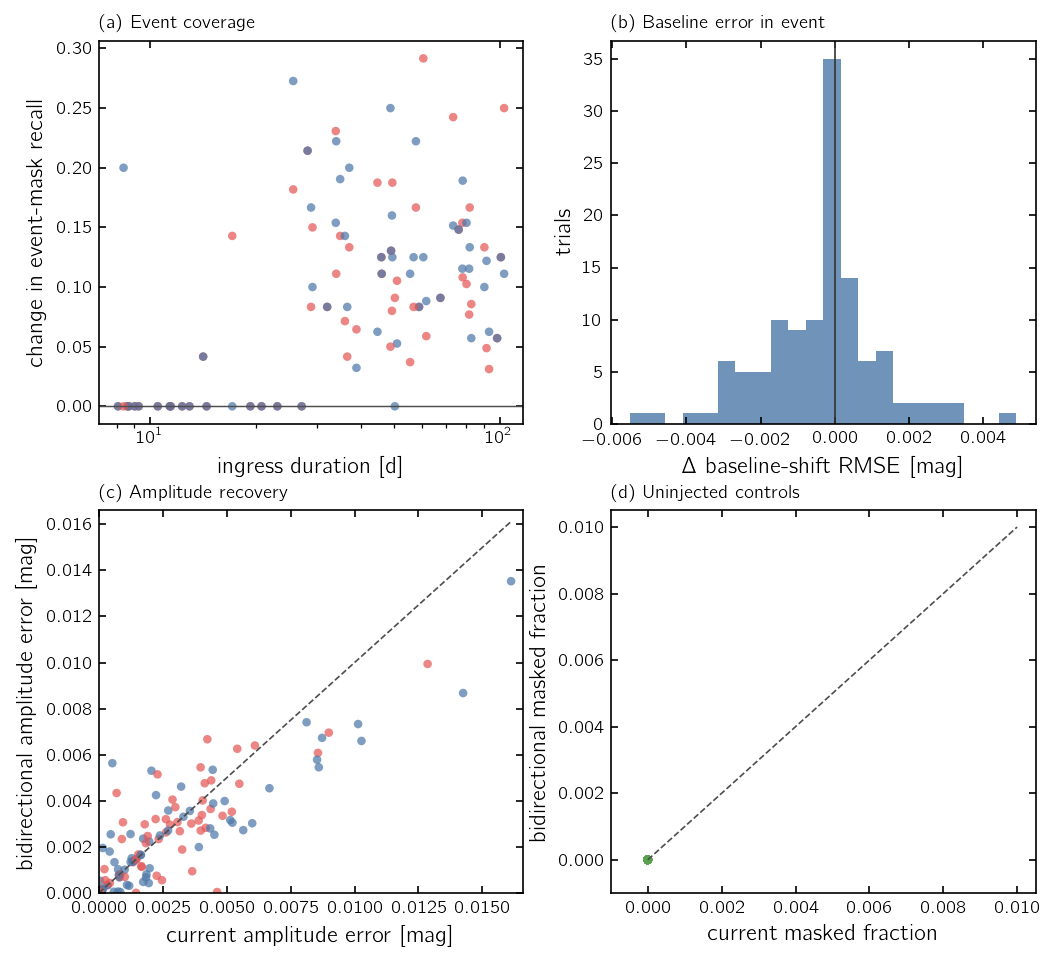

/Users/calder/code/malca/output/pdf/baseline_methods/mask_direction_comparison/bidirectional_mask_paired_trials.pdf


In [6]:
with plt.rc_context(PUBLICATION_STYLE):
    fig, axes = plt.subplots(2, 2, figsize=(FIG_TWO_COL_WIDTH, 6.3))

    colors = event_deltas["event_kind"].map(
        {"dimming": "#4C78A8", "brightening": "#E45756"}
    )
    axes[0, 0].scatter(
        event_deltas["rise_days"],
        event_deltas["mask_recall_delta"],
        c=colors,
        s=17,
        alpha=0.72,
        edgecolors="none",
    )
    axes[0, 0].axhline(0.0, color="0.3", linewidth=0.7)
    axes[0, 0].set_xscale("log")
    axes[0, 0].set_xlabel("ingress duration [d]")
    axes[0, 0].set_ylabel("change in event-mask recall")
    axes[0, 0].set_title("(a) Event coverage", loc="left", fontsize=9)

    axes[0, 1].hist(
        event_deltas["event_rmse_delta_mag"],
        bins=22,
        color="#4C78A8",
        alpha=0.8,
    )
    axes[0, 1].axvline(0.0, color="0.2", linewidth=0.8)
    axes[0, 1].set_xlabel(r"$\Delta$ baseline-shift RMSE [mag]")
    axes[0, 1].set_ylabel("trials")
    axes[0, 1].set_title("(b) Baseline error in event", loc="left", fontsize=9)

    max_error = float(
        np.nanmax(
            event_deltas[
                ["current_amplitude_error_mag", "bidirectional_amplitude_error_mag"]
            ].to_numpy(float)
        )
    )
    axes[1, 0].scatter(
        event_deltas["current_amplitude_error_mag"],
        event_deltas["bidirectional_amplitude_error_mag"],
        c=colors,
        s=17,
        alpha=0.72,
        edgecolors="none",
    )
    axes[1, 0].plot([0, max_error], [0, max_error], "--", color="0.3", linewidth=0.8)
    axes[1, 0].set_xlim(0, max_error * 1.03)
    axes[1, 0].set_ylim(0, max_error * 1.03)
    axes[1, 0].set_xlabel("current amplitude error [mag]")
    axes[1, 0].set_ylabel("bidirectional amplitude error [mag]")
    axes[1, 0].set_title("(c) Amplitude recovery", loc="left", fontsize=9)

    axes[1, 1].scatter(
        control_deltas["current_mask_fraction"],
        control_deltas["bidirectional_mask_fraction"],
        s=18,
        color="#59A14F",
        alpha=0.75,
        edgecolors="none",
    )
    control_max = max(
        0.01,
        float(
            np.nanmax(
                control_deltas[
                    ["current_mask_fraction", "bidirectional_mask_fraction"]
                ].to_numpy(float)
            )
        ),
    )
    axes[1, 1].plot(
        [0, control_max], [0, control_max], "--", color="0.3", linewidth=0.8
    )
    axes[1, 1].set_xlim(-0.001, control_max * 1.05)
    axes[1, 1].set_ylim(-0.001, control_max * 1.05)
    axes[1, 1].set_xlabel("current masked fraction")
    axes[1, 1].set_ylabel("bidirectional masked fraction")
    axes[1, 1].set_title("(d) Uninjected controls", loc="left", fontsize=9)

    for ax in axes.ravel():
        ax.tick_params(direction="in", top=True, right=True)
    finalize_publication_figure(fig)
    fig.savefig(MONTE_CARLO_PDF)
    fig.savefig(MONTE_CARLO_PNG, dpi=220)
    plt.show()

print(MONTE_CARLO_PDF)


,camera,points,current_masked,bidirectional_masked,added_by_bidirectional,removed_by_bidirectional,median_abs_baseline_delta_mag,max_abs_baseline_delta_mag,current_source,bidirectional_source
0,3,198,72,72,0,0,0.0,0.0,masked_gp,masked_gp
1,4,355,114,114,0,0,0.0,0.0,masked_gp,masked_gp
2,5,235,100,100,0,0,0.0,0.0,masked_gp,masked_gp
3,6,212,125,125,0,0,0.0,0.0,masked_gp,masked_gp
4,7,256,157,157,0,0,0.0,0.0,masked_gp,masked_gp


Current masked: 568
Bidirectional masked: 568


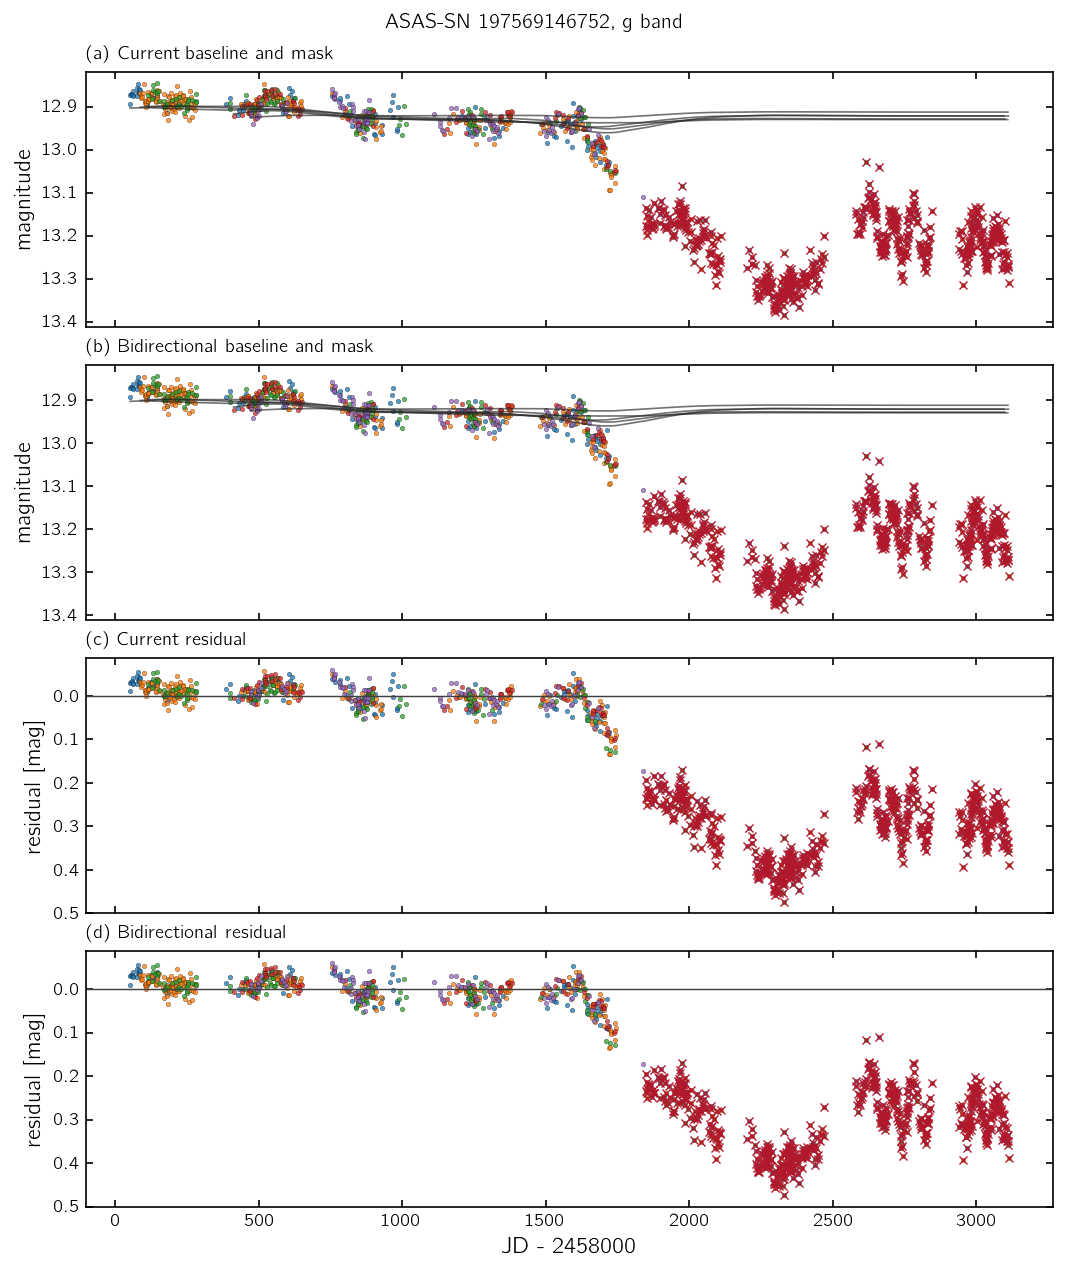

/Users/calder/code/malca/output/pdf/baseline_methods/mask_direction_comparison/bidirectional_mask_real_197569146752_g.csv
/Users/calder/code/malca/output/pdf/baseline_methods/mask_direction_comparison/bidirectional_mask_real_197569146752_g.pdf


In [7]:
canonical = load_lightcurve_df(LIGHTCURVE_PATH, apply_quality=True)
cleaned = clean_lc(to_asassn_algorithm_frame(canonical)).reset_index(drop=True)
bands = pd.to_numeric(cleaned["v_g_band"], errors="coerce")
real_lightcurve = cleaned.loc[np.isclose(bands, 0.0)].copy().reset_index(drop=True)
if real_lightcurve.empty:
    raise ValueError(f"No g-band data found for {TARGET_ID}.")

real_pair = run_baseline_pair(real_lightcurve)
real_current = real_pair["current"]
real_bidirectional = real_pair["bidirectional"]

real_rows = []
for camera in sorted(real_lightcurve["camera#"].dropna().unique(), key=str):
    camera_mask = real_lightcurve["camera#"].astype(str).eq(str(camera)).to_numpy()
    current_mask = (
        real_current["is_masked"].fillna(False).to_numpy(bool) & camera_mask
    )
    bidirectional_mask = (
        real_bidirectional["is_masked"].fillna(False).to_numpy(bool) & camera_mask
    )
    baseline_delta = (
        real_bidirectional.loc[camera_mask, "baseline"].to_numpy(float)
        - real_current.loc[camera_mask, "baseline"].to_numpy(float)
    )
    real_rows.append(
        {
            "camera": camera,
            "points": int(camera_mask.sum()),
            "current_masked": int(current_mask.sum()),
            "bidirectional_masked": int(bidirectional_mask.sum()),
            "added_by_bidirectional": int(
                np.count_nonzero(bidirectional_mask & ~current_mask)
            ),
            "removed_by_bidirectional": int(
                np.count_nonzero(current_mask & ~bidirectional_mask)
            ),
            "median_abs_baseline_delta_mag": float(
                np.nanmedian(np.abs(baseline_delta))
            ),
            "max_abs_baseline_delta_mag": float(
                np.nanmax(np.abs(baseline_delta))
            ),
            "current_source": ",".join(
                sorted(
                    real_current.loc[camera_mask, "baseline_source"]
                    .dropna()
                    .astype(str)
                    .unique()
                )
            ),
            "bidirectional_source": ",".join(
                sorted(
                    real_bidirectional.loc[camera_mask, "baseline_source"]
                    .dropna()
                    .astype(str)
                    .unique()
                )
            ),
        }
    )

real_metrics = pd.DataFrame(real_rows)
real_metrics.to_csv(REAL_METRICS_CSV, index=False)
display(real_metrics)
print("Current masked:", int(real_current["is_masked"].sum()))
print("Bidirectional masked:", int(real_bidirectional["is_masked"].sum()))

real_added = (
    real_bidirectional["is_masked"].fillna(False).to_numpy(bool)
    & ~real_current["is_masked"].fillna(False).to_numpy(bool)
)


def plot_real_panel(ax, frame, title, *, added_mask=None, residual=False):
    y_column = "resid" if residual else "mag"
    for camera, sub in frame.groupby("camera#", sort=True):
        sub = sub.sort_values("JD")
        indices = sub.index.to_numpy()
        x = sub["JD"].to_numpy(float) - 2458000.0
        ax.scatter(
            x, sub[y_column], s=5, alpha=0.75,
            edgecolors="black", linewidths=0.15,
        )
        if not residual:
            ax.plot(x, sub["baseline"], color="0.15", linewidth=0.8, alpha=0.65)
        masked = sub["is_masked"].fillna(False).to_numpy(bool)
        if masked.any():
            ax.scatter(
                x[masked], sub.loc[masked, y_column], marker="x",
                s=15, color="#B2182B", linewidths=0.65, zorder=5,
            )
        if added_mask is not None:
            added_here = np.asarray(added_mask, bool)[indices]
            if added_here.any():
                ax.scatter(
                    x[added_here],
                    sub.loc[added_here, y_column],
                    facecolors="none",
                    edgecolors="#E69F00",
                    s=32,
                    linewidths=0.8,
                    zorder=6,
                )
    if residual:
        ax.axhline(0.0, color="0.25", linewidth=0.7)
    ax.invert_yaxis()
    ax.set_ylabel("residual [mag]" if residual else "magnitude")
    ax.set_title(title, loc="left", fontsize=9)


with plt.rc_context(PUBLICATION_STYLE):
    fig, axes = plt.subplots(4, 1, figsize=(FIG_TWO_COL_WIDTH, 8.5), sharex=True)
    plot_real_panel(axes[0], real_current, "(a) Current baseline and mask")
    plot_real_panel(
        axes[1],
        real_bidirectional,
        "(b) Bidirectional baseline and mask",
        added_mask=real_added,
    )
    plot_real_panel(axes[2], real_current, "(c) Current residual", residual=True)
    plot_real_panel(
        axes[3],
        real_bidirectional,
        "(d) Bidirectional residual",
        added_mask=real_added,
        residual=True,
    )
    axes[-1].set_xlabel("JD - 2458000")
    for ax in axes:
        ax.tick_params(direction="in", top=True, right=True)
    fig.suptitle(f"ASAS-SN {TARGET_ID}, g band", fontsize=10)
    finalize_publication_figure(fig, rect=(0, 0, 1, 0.98))
    fig.savefig(REAL_PDF)
    fig.savefig(REAL_PNG, dpi=220)
    plt.show()

print(REAL_METRICS_CSV)
print(REAL_PDF)


In [8]:
control_mask_change = (
    control_deltas["bidirectional_mask_fraction"]
    - control_deltas["current_mask_fraction"]
)


def decision_row(metric, values, preferred_direction):
    values = pd.Series(values, dtype=float).dropna()
    if preferred_direction == "positive":
        improved = values > 0
        worsened = values < 0
    elif preferred_direction == "negative":
        improved = values < 0
        worsened = values > 0
    else:
        improved = pd.Series(False, index=values.index)
        worsened = values != 0
    return {
        "metric": metric,
        "median_delta": float(values.median()),
        "mean_delta": float(values.mean()),
        "improved_trials": int(improved.sum()),
        "unchanged_trials": int((values == 0).sum()),
        "worsened_trials": int(worsened.sum()),
        "preferred_direction": preferred_direction,
    }


decision_summary = pd.DataFrame(
    [
        decision_row(
            "event mask recall",
            event_deltas["mask_recall_delta"],
            "positive",
        ),
        decision_row(
            "paired-control baseline shift RMSE [mag]",
            event_deltas["event_rmse_delta_mag"],
            "negative",
        ),
        decision_row(
            "paired-control absolute amplitude error [mag]",
            event_deltas["amplitude_error_delta_mag"],
            "negative",
        ),
        decision_row(
            "uninjected-control masked fraction",
            control_mask_change,
            "near zero",
        ),
    ]
)
display(decision_summary)

print(
    "Interpretation: the bidirectional rule is promising when it increases event "
    "coverage and reduces event-region baseline/amplitude error without materially "
    "increasing masking or baseline error in uninjected controls. This notebook is "
    "a focused algorithm test, not authorization to change production code."
)


,metric,median_delta,mean_delta,improved_trials,unchanged_trials,worsened_trials,preferred_direction
0,event mask recall,0.086975,0.090918,87,33,0,positive
1,paired-control baseline shift RMSE [mag],0.000000,-0.000343,54,20,46,negative
2,paired-control absolute amplitude error [mag],0.000000,-0.000318,54,20,46,negative
3,uninjected-control masked fraction,0.000000,0.000000,0,60,0,near zero


Interpretation: the bidirectional rule is promising when it increases event coverage and reduces event-region baseline/amplitude error without materially increasing masking or baseline error in uninjected controls. This notebook is a focused algorithm test, not authorization to change production code.
